# Perceptron

In [5]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [12]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from models.perceptron import Perceptron
from sklearn.linear_model import Perceptron as SklearnPerceptron

from metrics.classification import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from utils.functions import (
    unit_step_func,
)
from utils.plots import plot_decision_boundary

## Linearly Separable Dataset

In [7]:
# Generation
X, y = make_blobs(
    n_samples=500,
    centers=2,
    cluster_std=1.2,
    random_state=42,
)

# Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

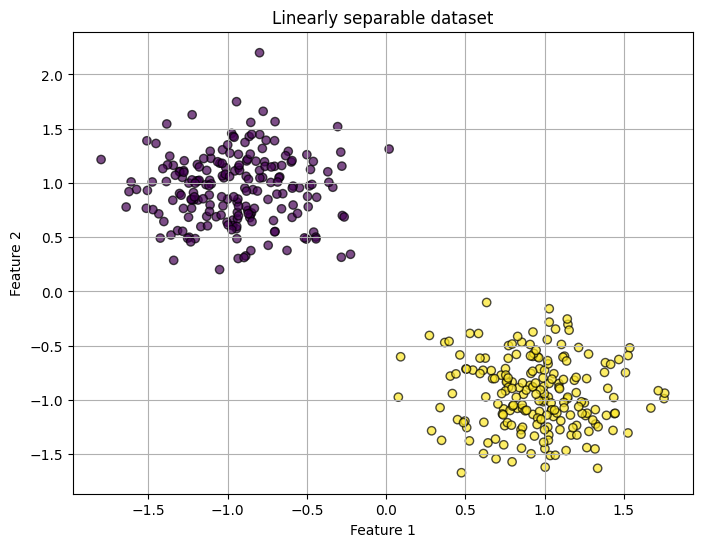

In [8]:
# Plot
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    edgecolor="k",
    alpha=0.7,
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Linearly separable dataset")
plt.grid(True)

plt.show()

### Fitting

In [9]:
# Scratch
scratch_perceptron = Perceptron(lr=0.01, n_iters=1000, activation_func=unit_step_func)
scratch_perceptron.fit(X_train_scaled, y_train)

scratch_preds = scratch_perceptron.predict(X_test_scaled)

# Sklearn
sklearn_perceptron = SklearnPerceptron(
    max_iter=1000,
    eta0=0.01,
    random_state=42,
    tol=None,
)

sklearn_perceptron.fit(X_train_scaled, y_train)

sklearn_preds = sklearn_perceptron.predict(X_test_scaled)

In [10]:
# Results

results = {
    "From scratch": {
        "Accuracy": accuracy_score(y_test, scratch_preds),
        "Precision": precision_score(y_test, scratch_preds),
        "Recall": recall_score(y_test, scratch_preds),
        "F1": f1_score(y_test, scratch_preds),
    },
    "Scikit-learn": {
        "Accuracy": accuracy_score(y_test, sklearn_preds),
        "Precision": precision_score(y_test, sklearn_preds),
        "Recall": recall_score(y_test, sklearn_preds),
        "F1": f1_score(y_test, sklearn_preds),
    },
}

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1
From scratch,1.0,1.0,1.0,1.0
Scikit-learn,1.0,1.0,1.0,1.0


### Error History Plot
Since this is a linearly separable dataset, the errors go to 0 very quickly

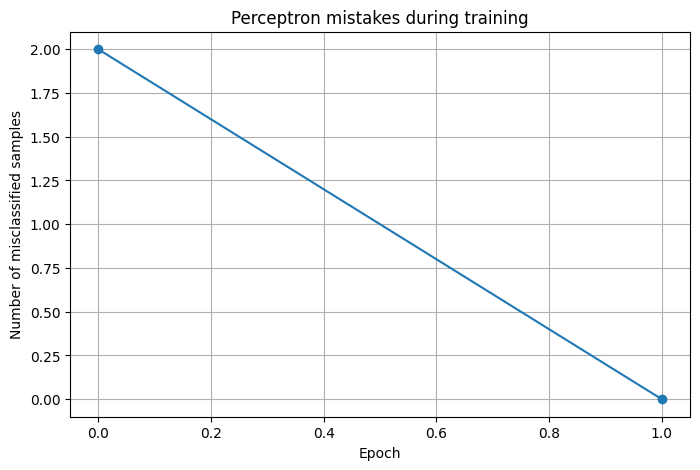

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(scratch_perceptron.loss_history, marker="o")

plt.xlabel("Epoch")
plt.ylabel("Number of misclassified samples")
plt.title("Perceptron mistakes during training")
plt.grid(True)

plt.show()

### Decision Boundary Plot
The plots differ slightly, even if each model perfectly separates the two classes and achieve the same predictions, because the perceptron does not find the optimal separating hyperplane, but just one of the many.

Unlike SVM, it does not maximize the margin, therefore multiple solutions are equally valid.

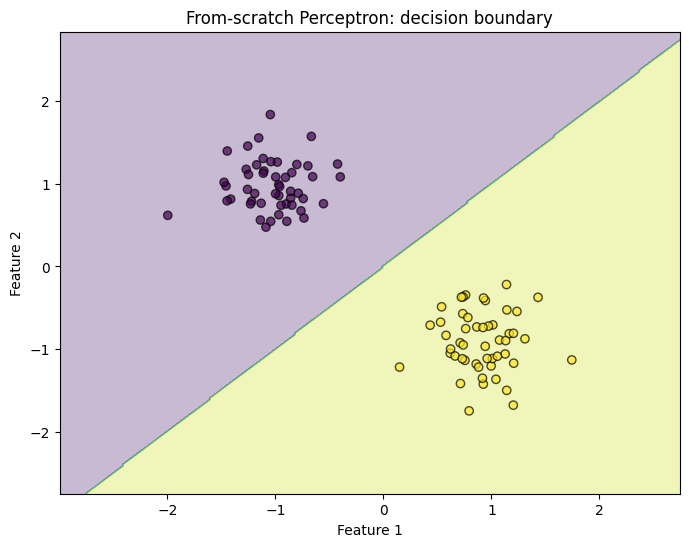

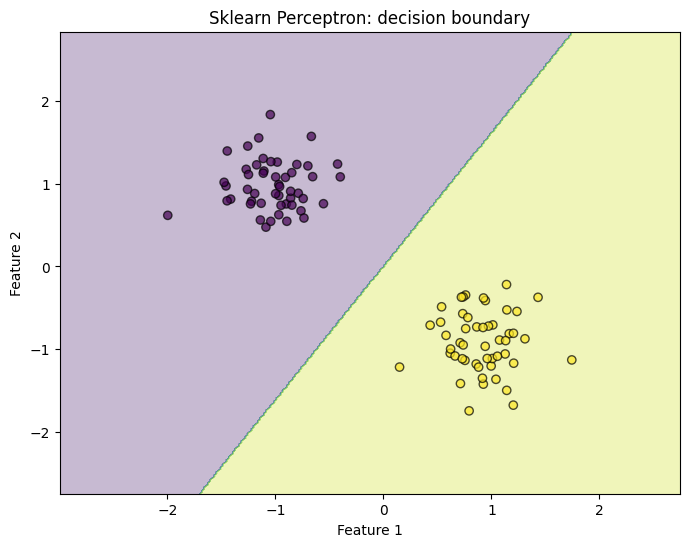

In [15]:
plot_decision_boundary(
    scratch_perceptron,
    X_test_scaled,
    y_test,
    "From-scratch Perceptron: decision boundary"
)

plot_decision_boundary(
    sklearn_perceptron,
    X_test_scaled,
    y_test,
    "Sklearn Perceptron: decision boundary"
)

## Nonlinearly Separable Dataset
In this case, the number of mistakes never reaches 0, and the convergence theorem no longer applies. 

The decision boundary is still a line, and the performance on the test set is significantly worse than logistic regression or SVM.

For the nonlinear dataset, sklearn and the scratch perceptron can differ because the problem is not linearly separable. The perceptron has no unique optimum there; it keeps updating depending on sample order, stopping behavior, initialization, tolerance, and implementation details. The end result is similar, but not the same.

In [17]:
# Generation
X, y = make_moons(
    n_samples=500,
    noise=0.25,
    random_state=42,
)

# Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

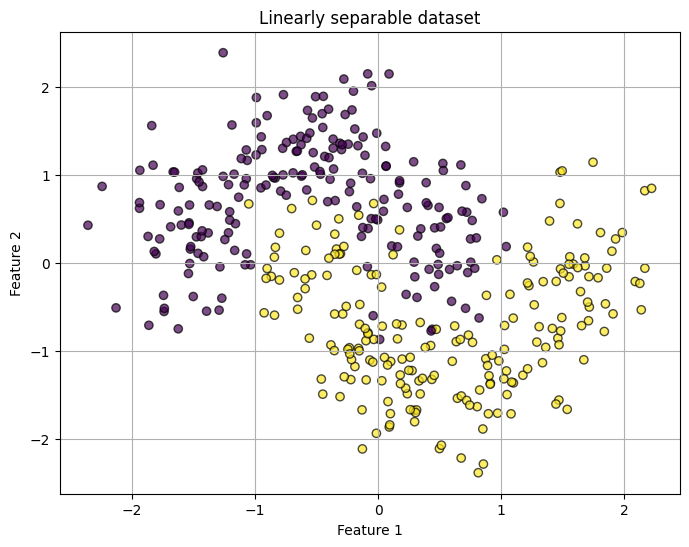

In [18]:
# Plot
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    edgecolor="k",
    alpha=0.7,
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Linearly separable dataset")
plt.grid(True)

plt.show()

### Fitting

In [19]:
# Scratch
scratch_perceptron = Perceptron(lr=0.01, n_iters=1000, activation_func=unit_step_func)
scratch_perceptron.fit(X_train_scaled, y_train)

scratch_preds = scratch_perceptron.predict(X_test_scaled)

# Sklearn
sklearn_perceptron = SklearnPerceptron(
    max_iter=1000,
    eta0=0.01,
    random_state=42,
    tol=None,
)

sklearn_perceptron.fit(X_train_scaled, y_train)

sklearn_preds = sklearn_perceptron.predict(X_test_scaled)

In [20]:
# Results

results = {
    "From scratch": {
        "Accuracy": accuracy_score(y_test, scratch_preds),
        "Precision": precision_score(y_test, scratch_preds),
        "Recall": recall_score(y_test, scratch_preds),
        "F1": f1_score(y_test, scratch_preds),
    },
    "Scikit-learn": {
        "Accuracy": accuracy_score(y_test, sklearn_preds),
        "Precision": precision_score(y_test, sklearn_preds),
        "Recall": recall_score(y_test, sklearn_preds),
        "F1": f1_score(y_test, sklearn_preds),
    },
}

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1
From scratch,0.83,0.80,0.88,0.838095
Scikit-learn,0.82,0.75,0.96,0.842105


### Error History Plot

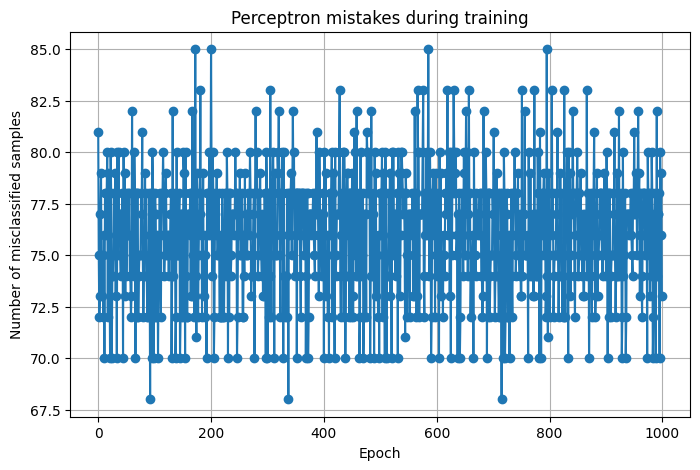

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(scratch_perceptron.loss_history, marker="o")

plt.xlabel("Epoch")
plt.ylabel("Number of misclassified samples")
plt.title("Perceptron mistakes during training")
plt.grid(True)

plt.show()

### Decision Boundary Plot

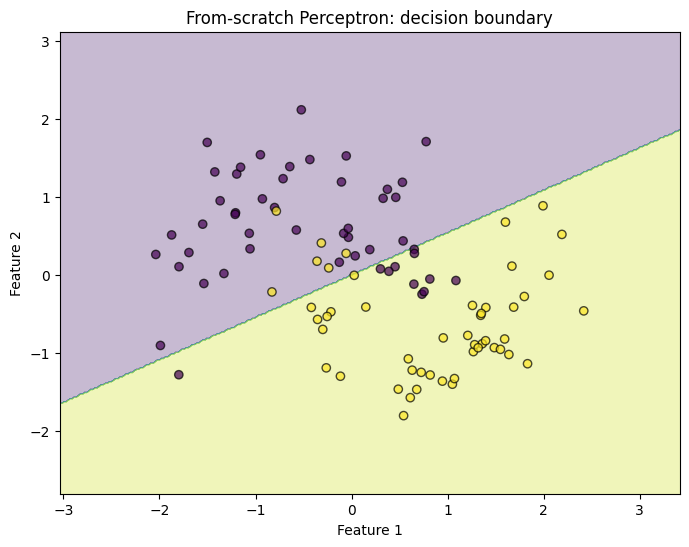

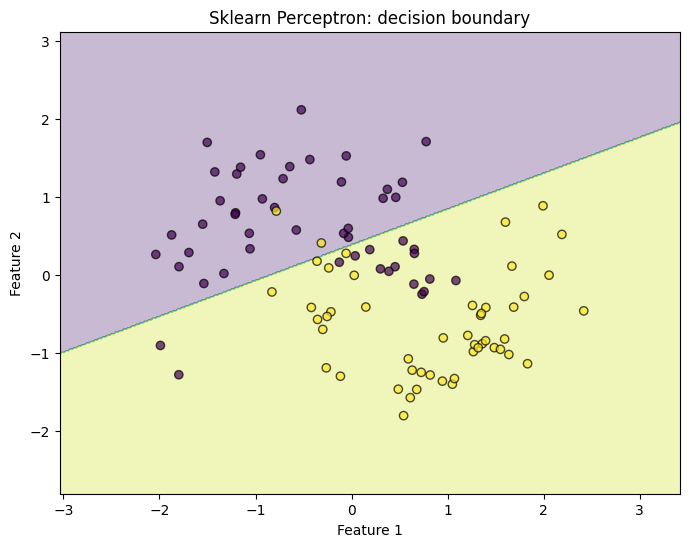

In [22]:
plot_decision_boundary(
    scratch_perceptron,
    X_test_scaled,
    y_test,
    "From-scratch Perceptron: decision boundary"
)

plot_decision_boundary(
    sklearn_perceptron,
    X_test_scaled,
    y_test,
    "Sklearn Perceptron: decision boundary"
)